# Comparison to Galacticus Data

Now we want to compare SatGen's and our stripping procedure to Galacticus. In order to do so we use the data at 100 snapshots from the Galacticus output which we were provided with. Here we load the data and visualize it to get familiar with it.

In [1]:
import h5py, numpy as np, sys

FILE = "galacticus_for_max.hdf5"

Find the structure of the file

In [2]:
def print_hdf5_structure(name, obj):
    indent = "  " * name.count("/")
    if isinstance(obj, h5py.Group):
        print(f"{indent}[Group] {name}/")
    elif isinstance(obj, h5py.Dataset):
        print(f"{indent}[Dataset] {name}: shape={obj.shape}, dtype={obj.dtype}")

with h5py.File(FILE, "r") as f:
    print(f"Root groups: {list(f.keys())}\n")
    f.visititems(print_hdf5_structure)

Root groups: ['Build', 'Outputs', 'Parameters', 'Version', 'massAccretionHistories']

[Group] Build/
[Group] Outputs/
  [Group] Outputs/Output1/
    [Group] Outputs/Output1/mergerTree1/
      [Dataset] Outputs/Output1/mergerTree1/basicMass: shape=(), dtype=object
      [Dataset] Outputs/Output1/mergerTree1/basicTimeLastIsolated: shape=(), dtype=object
      [Dataset] Outputs/Output1/mergerTree1/blackHoleMass: shape=(), dtype=object
      [Dataset] Outputs/Output1/mergerTree1/blackHoleSpin: shape=(), dtype=object
      [Dataset] Outputs/Output1/mergerTree1/darkMatterProfileScale: shape=(), dtype=object
      [Dataset] Outputs/Output1/mergerTree1/diskAbundancesGasMetals: shape=(), dtype=object
      [Dataset] Outputs/Output1/mergerTree1/diskAbundancesStellarMetals: shape=(), dtype=object
      [Dataset] Outputs/Output1/mergerTree1/diskAngularMomentum: shape=(), dtype=object
      [Dataset] Outputs/Output1/mergerTree1/diskMassGas: shape=(), dtype=object
      [Dataset] Outputs/Output1/mer

Available Redshifts

In [3]:
with h5py.File(FILE, "r") as f:
    redshifts = sorted([f["Outputs"][k]["nodeData"]["redshift"][0] 
                        for k in f["Outputs"]])
print("Available redshifts:", np.round(redshifts, 3))

Available redshifts: [0.000e+00 9.000e-03 1.900e-02 2.900e-02 3.800e-02 4.800e-02 5.800e-02
 6.800e-02 7.900e-02 8.900e-02 1.000e-01 1.110e-01 1.220e-01 1.330e-01
 1.440e-01 1.560e-01 1.680e-01 1.800e-01 1.920e-01 2.040e-01 2.170e-01
 2.290e-01 2.420e-01 2.560e-01 2.690e-01 2.830e-01 2.970e-01 3.110e-01
 3.260e-01 3.400e-01 3.550e-01 3.710e-01 3.870e-01 4.030e-01 4.190e-01
 4.360e-01 4.530e-01 4.710e-01 4.890e-01 5.070e-01 5.260e-01 5.450e-01
 5.650e-01 5.850e-01 6.060e-01 6.270e-01 6.490e-01 6.710e-01 6.940e-01
 7.180e-01 7.420e-01 7.680e-01 7.940e-01 8.200e-01 8.480e-01 8.760e-01
 9.060e-01 9.360e-01 9.680e-01 1.000e+00 1.034e+00 1.069e+00 1.106e+00
 1.143e+00 1.183e+00 1.224e+00 1.267e+00 1.312e+00 1.359e+00 1.408e+00
 1.459e+00 1.513e+00 1.570e+00 1.630e+00 1.694e+00 1.761e+00 1.832e+00
 1.908e+00 1.989e+00 2.075e+00 2.168e+00 2.267e+00 2.375e+00 2.491e+00
 2.618e+00 2.756e+00 2.908e+00 3.076e+00 3.263e+00 3.473e+00 3.710e+00
 3.980e+00 4.293e+00 4.659e+00 5.095e+00 5.626e+00 6.289

Filter for a specific redshift

In [22]:
def produce_snapshot_data(file, target_z=0.0):
    with h5py.File(file, "r") as f:
        snaps = {k: {d: f["Outputs"][k]["nodeData"][d][()] 
                      for d in f["Outputs"][k]["nodeData"]} 
                     for k in f["Outputs"]}
    
    snap = min(snaps.values(), key=lambda s: abs(s["redshift"][0] - target_z))
    z    = snap["redshift"][0]
    mask = snap["nodeIsIsolated"] == 0
    
    cols = ["nodeIndex","positionOrbitalX","positionOrbitalY","positionOrbitalZ",
            "velocityOrbitalX","velocityOrbitalY","velocityOrbitalZ",
            "basicMass","satelliteBoundMass","darkMatterProfileScale",
            "satellitePericenterRadius","satelliteApocenterRadius","satelliteDistanceMinimum"]
    
    print("Columns:", "  ".join(cols))
    
    data = {c: snap[c][mask] for c in cols}
    return z, data

In [23]:
target_z = 0.0

with h5py.File(FILE, "r") as f:
    snaps = {k: {d: f["Outputs"][k]["nodeData"][d][()] 
                 for d in f["Outputs"][k]["nodeData"]} 
             for k in f["Outputs"]}

snap = min(snaps.values(), key=lambda s: abs(s["redshift"][0] - target_z))
z    = snap["redshift"][0]
mask = snap["nodeIsIsolated"] == 0

host_mask = snap["nodeIsIsolated"] == 1
host_idx  = np.argmax(snap["basicMass"][host_mask])
print(f"Host: nodeIndex={snap['nodeIndex'][host_mask][host_idx]}  "
      f"M_vir={snap['basicMass'][host_mask][host_idx]:.3e} Msun  "
      f"r_s={snap['darkMatterProfileScale'][host_mask][host_idx]*1e3:.3f} kpc")

print(f"Snapshot z={z:.4f} | {mask.sum()} subhalos")

Host: nodeIndex=1  M_vir=1.000e+08 Msun  r_s=0.330 kpc
Snapshot z=0.0000 | 140 subhalos


Print Subhalo Properties

In [10]:
cols = ["nodeIndex","positionOrbitalX","positionOrbitalY","positionOrbitalZ",
        "velocityOrbitalX","velocityOrbitalY","velocityOrbitalZ",
        "basicMass","satelliteBoundMass","darkMatterProfileScale",
        "satellitePericenterRadius","satelliteApocenterRadius","satelliteDistanceMinimum"]

header = "nodeIndex  x[Mpc]  y[Mpc]  z[Mpc]  vx[km/s]  vy[km/s]  vz[km/s]  " \
         "M_vir[Msun]  M_bound[Msun]  rs[Mpc]  r_peri[Mpc]  r_apo[Mpc]  r_min[Mpc]"

data = np.column_stack([snap[c][mask] for c in cols])
print(data[:5])  # Print first 5 rows of the data

[[ 2.00000000e+00  7.77735927e-03 -3.81534518e-03 -7.23908314e-03
  -2.94649432e+00  3.91703218e+00  5.55036798e+00  5.72966122e+05
   5.72966122e+05  3.00108321e-05  1.73701513e-03  3.06521501e-02
   1.12893091e-02]
 [ 4.00000000e+00 -2.16530921e-03 -1.63678610e-03  3.74403200e-03
  -6.33091390e+00  7.14209246e+00  4.34779935e+00  6.41447146e+06
   3.39396869e+05  9.66072953e-05  3.18586187e-03  1.82994506e-02
   4.00971073e-03]
 [ 8.68200000e+03 -7.46420738e-04  4.89109084e-04  1.20989877e-04
   6.62603309e+00 -5.96271389e+00  3.13920604e+00  1.08562777e+04
   4.03503964e+03  3.61552265e-05  1.87166322e-04  2.05463678e-03
   2.29483276e-04]
 [ 9.14900000e+03 -4.13886595e-05  2.88079549e-04 -1.74357503e-04
   5.32315962e-01  2.10915757e+00 -3.70962876e+00  1.53069786e+04
   1.86311051e+01  1.45462083e-05  4.26147061e-05  5.10440017e-04
   5.34944401e-05]
 [ 9.36100000e+03 -9.62173092e-06  3.37766373e-05 -6.88254958e-05
   6.15994187e-01  1.50033692e-01 -1.82039131e+00  1.17314961e+04


Check mass vs radius distribution

Columns: nodeIndex  positionOrbitalX  positionOrbitalY  positionOrbitalZ  velocityOrbitalX  velocityOrbitalY  velocityOrbitalZ  basicMass  satelliteBoundMass  darkMatterProfileScale  satellitePericenterRadius  satelliteApocenterRadius  satelliteDistanceMinimum
z=0: Mass range: 1.487e+00 - 5.730e+05 Msun
z= 0: Radius range: 4.509 - 28470.215 pc
Columns: nodeIndex  positionOrbitalX  positionOrbitalY  positionOrbitalZ  velocityOrbitalX  velocityOrbitalY  velocityOrbitalZ  basicMass  satelliteBoundMass  darkMatterProfileScale  satellitePericenterRadius  satelliteApocenterRadius  satelliteDistanceMinimum
z=10: Mass range: 3.186e+00 - 1.326e+05 Msun
z= 10: Radius range: 11.245 - 1648.016 pc


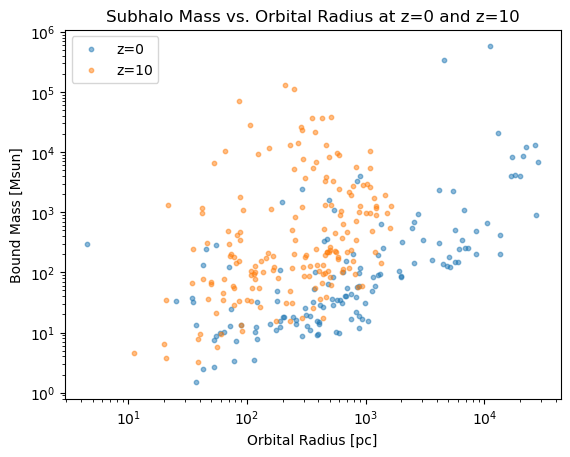

In [21]:
import matplotlib.pyplot as plt

_, data_0 = produce_snapshot_data(FILE, 0.0)
mass_0 = data_0["satelliteBoundMass"]
print(f"z=0: Mass range: {mass_0.min():.3e} - {mass_0.max():.3e} Msun")
radius_0 = 1e6*np.sqrt(data_0["positionOrbitalX"]**2 + data_0["positionOrbitalY"]**2 + data_0["positionOrbitalZ"]**2)
print(f"z= 0: Radius range: {radius_0.min():.3f} - {radius_0.max():.3f} pc")

_, data_10 = produce_snapshot_data(FILE, 10.0)
mass_10 = data_10["satelliteBoundMass"]
print(f"z=10: Mass range: {mass_10.min():.3e} - {mass_10.max():.3e} Msun")
radius_10 = 1e6*np.sqrt(data_10["positionOrbitalX"]**2 + data_10["positionOrbitalY"]**2 + data_10["positionOrbitalZ"]**2)
print(f"z= 10: Radius range: {radius_10.min():.3f} - {radius_10.max():.3f} pc")

fig, ax = plt.subplots()
ax.scatter(radius_0, mass_0, s=10, alpha=0.5, label='z=0')
ax.scatter(radius_10, mass_10, s=10, alpha=0.5, label='z=10')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Orbital Radius [pc]')
ax.set_ylabel('Bound Mass [Msun]')
ax.set_title(f'Subhalo Mass vs. Orbital Radius at z=0 and z=10')
ax.legend()
plt.show()

Let us look at the host evolution

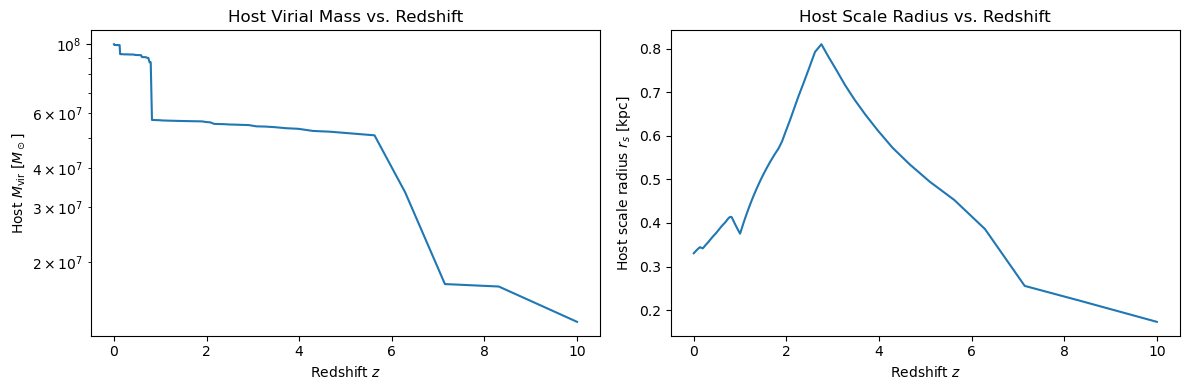

In [27]:
with h5py.File(FILE, "r") as f:
    snaps = {k: {d: f["Outputs"][k]["nodeData"][d][()] 
                    for d in f["Outputs"][k]["nodeData"]} 
                for k in f["Outputs"]}
    host_z, host_mass, host_rs = [], [], []
    redshifts = sorted([f["Outputs"][k]["nodeData"]["redshift"][0] 
                        for k in f["Outputs"]])

    for target_z in redshifts:
        snap = min(snaps.values(), key=lambda s: abs(s["redshift"][0] - target_z))
        z    = snap["redshift"][0]
        host_z.append(z)
        host_mask = snap["nodeIsIsolated"] == 1
        host_idx  = np.argmax(snap["basicMass"][host_mask])
        host_mass.append(snap['basicMass'][host_mask][host_idx])
        host_rs.append(snap['darkMatterProfileScale'][host_mask][host_idx]*1e3)  # Convert Mpc to kpc


host_z    = np.array(host_z)
host_mass = np.array(host_mass)
host_rs   = np.array(host_rs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(host_z, host_mass)
ax1.set_xlabel("Redshift $z$")
ax1.set_ylabel(r"Host $M_\mathrm{vir}$ [$M_\odot$]")
ax1.set_yscale("log")
ax1.set_title("Host Virial Mass vs. Redshift")

ax2.plot(host_z, host_rs)
ax2.set_xlabel("Redshift $z$")
ax2.set_ylabel(r"Host scale radius $r_s$ [kpc]")
ax2.set_title("Host Scale Radius vs. Redshift")

plt.tight_layout()
plt.show()